In [2]:
import numpy
import itertools
import math
import gsd.hoomd
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


#Grabbing helper scripts
import md_Helpers.Create_Lattices as cl
import md_Helpers.Simulation_Helpers as sh
import md_Helpers.Logging_Helpers as lh
import md_Helpers.viz_helpers as vh
from md_Helpers.Project_Paths import THERMALIZED_STATES_ROOT


import importlib
importlib.reload(cl)
importlib.reload(sh)
importlib.reload(lh)
importlib.reload(vh)

<module 'md_Helpers.viz_helpers' from '/home/pnichols/MDsims/md_Helpers/viz_helpers.py'>

In [3]:
result = sh.get_or_make_thermalized_state(
    BoxLength=51.0,
    target_rho=0.4,
    kT=0.40,
    nsteps=100_000,
    overwrite = True
)

paths = result["paths"]

Created new fcc lattice
----------------------------
Target BoxLength = 51.0
Target rho = 0.4
Actual rho = 0.3668875470218845
Density error = -0.03311245297811555
Number of particles = 48668
Saved lattice to /exp/e961/data/MDsims-data/pnichols/Simple_Lattices/FCC/BoxLength_51.0/rho_0.40/lattice.gsd
Using GPU device
Final device: <hoomd.device.GPU object at 0x7f035b518ec0>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_51.0/rho_0.40/kT_0.40/randomization_nsteps_100000_log.hdf5
Stopped HDF5 logger
Wrote HDF5 metadata
Saved final state
GSD file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_51.0/rho_0.40/kT_0.40/randomization_nsteps_100000.gsd


In [5]:
print(result.keys())
print(result['created_new'])

dict_keys(['frame', 'simulation', 'paths', 'created_new'])
True


In [6]:
log_data = lh.read_hdf5_log(paths["log_path"])
log_data["metadata"]['attrs']

{'Lx': 51.0,
 'Ly': 51.0,
 'Lz': 51.0,
 'N': 48668,
 'actual_rho': 0.3668875470218845,
 'dt': 0.005,
 'epsilon_LJ': 1.0,
 'final_timestep': 100000,
 'kT': 0.4,
 'lj_mode': 'xplor',
 'log_period': 1000,
 'nsteps': 100000,
 'phase_name': 'randomization',
 'phase_separated': True,
 'r_cut_LJ': 2.5,
 'r_on_LJ': 2.0,
 'seed': 1,
 'sigma_LJ': 1.0,
 'starting_state_path': '/exp/e961/data/MDsims-data/pnichols/Simple_Lattices/FCC/BoxLength_51.0/rho_0.40/lattice.gsd',
 'target_rho': 0.4,
 'volume': 132651.0}

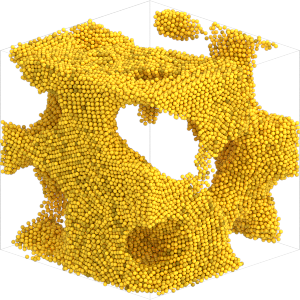

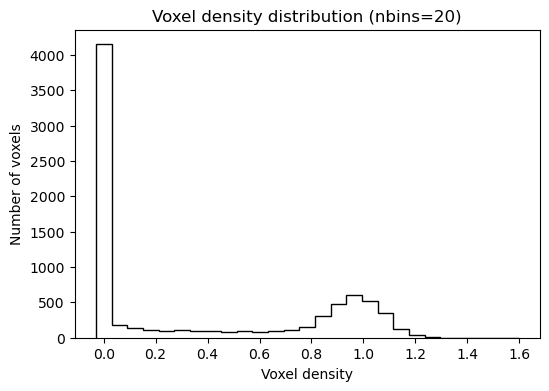

In [7]:
sim = result["simulation"]

display(vh.render(sim.state.get_snapshot()))

vh.plot_voxel_histogram(sim, nbins=20);

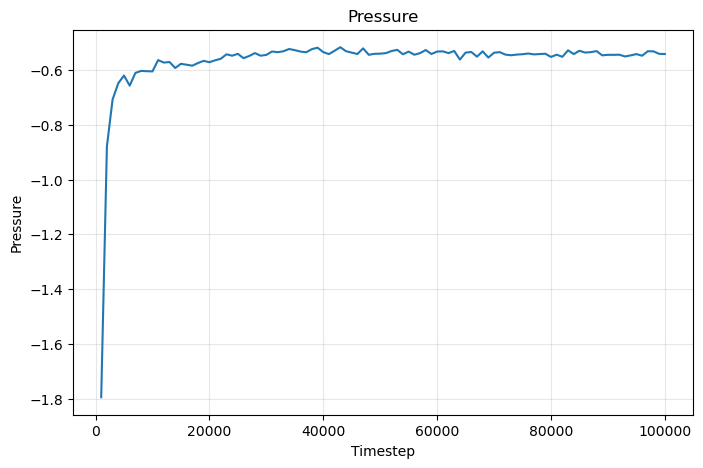

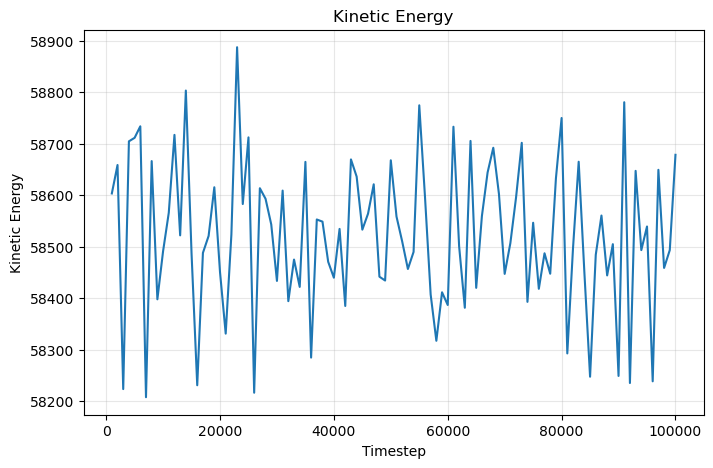

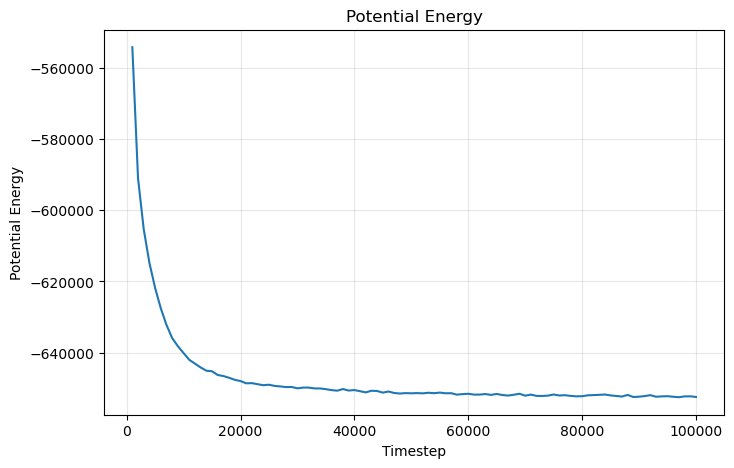

In [35]:
vh.plot_log_quantity(log_data, "pressure")
vh.plot_log_quantity(log_data, "kinetic_energy")
vh.plot_log_quantity(log_data, "potential_energy")

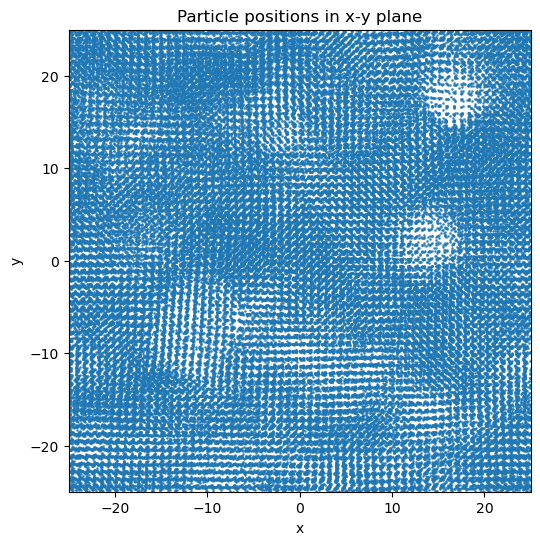

In [36]:
vh.plot_xy_particles(sim)

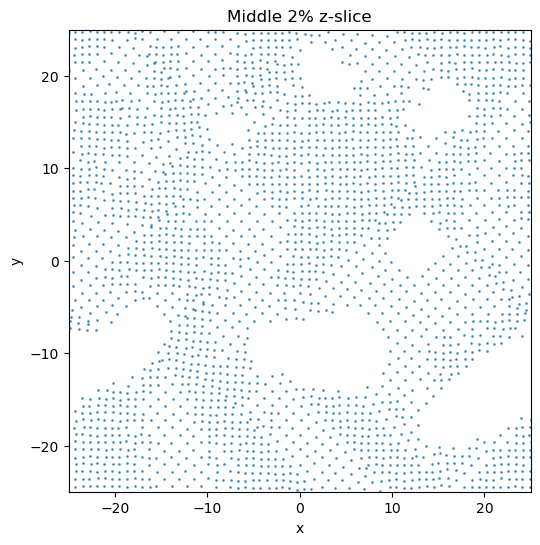

In [37]:
vh.plot_xy_slice(sim, fraction=0.025)

In [6]:
for i in range(10):
    sim = sh.make_simulation(frame, starting_state_path=lattice_path,kT = .4)
    nsteps = 500 * (i + 1)
    sh.thermalize_and_randomize(sim, nsteps=nsteps, phase_name="randomization", log = True)
    print(f"Finished nsteps = {nsteps}")

print("done")

Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f2346aeee90>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_500_log.hdf5
Stopped HDF5 logger
Wrote HDF5 metadata
Saved final state
GSD file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_500.gsd
Finished nsteps = 500
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f2346aedbd0>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_1000_log.hdf5
Stopped HDF5 logger
Wrote HDF5 metadata
Saved final state
GSD file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_1000.gsd
Finished nsteps = 1000
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f282b3c75c0>
S